In [1]:
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
workspace_root = next(
    path
    for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'shared').exists() and (path / 'artifacts').exists()
)
artifacts_root = workspace_root / 'artifacts' / 'ps-004-headcount-forecasting'
data_path = workspace_root / 'shared' / 'data' / '4_processed' / 'workforce_clean.parquet'
df = pl.read_parquet(data_path)
all_sector_df = df.filter(pl.col('sector') == 'All').sort(['profession', 'year'])
print(f"Filtered sector=='All' shape: {all_sector_df.shape}")
print(all_sector_df.head())
if all_sector_df.is_empty():
    print("No sector='All' rows found in the canonical parquet. Falling back to year-profession totals summed across sectors so the EDA can run.")
    analysis_df = (
        df.group_by(['year', 'profession'])
        .agg(pl.col('count').sum().alias('count'))
        .sort(['profession', 'year'])
    )
else:
    analysis_df = all_sector_df.select(['year', 'profession', 'count']).sort(['profession', 'year'])
print(f"Analysis shape: {analysis_df.shape}")
print(analysis_df.head())

Filtered sector=='All' shape: (0, 4)
shape: (0, 4)
┌──────┬────────┬───────┬────────────┐
│ year ┆ sector ┆ count ┆ profession │
│ ---  ┆ ---    ┆ ---   ┆ ---        │
│ i32  ┆ cat    ┆ i32   ┆ cat        │
╞══════╪════════╪═══════╪════════════╡
└──────┴────────┴───────┴────────────┘
No sector='All' rows found in the canonical parquet. Falling back to year-profession totals summed across sectors so the EDA can run.
Analysis shape: (48, 3)
shape: (5, 3)
┌──────┬────────────┬───────┐
│ year ┆ profession ┆ count │
│ ---  ┆ ---        ┆ ---   │
│ i32  ┆ cat        ┆ i32   │
╞══════╪════════════╪═══════╡
│ 2006 ┆ doctors    ┆ 6931  │
│ 2007 ┆ doctors    ┆ 7464  │
│ 2008 ┆ doctors    ┆ 7841  │
│ 2009 ┆ doctors    ┆ 8323  │
│ 2010 ┆ doctors    ┆ 9030  │
└──────┴────────────┴───────┘


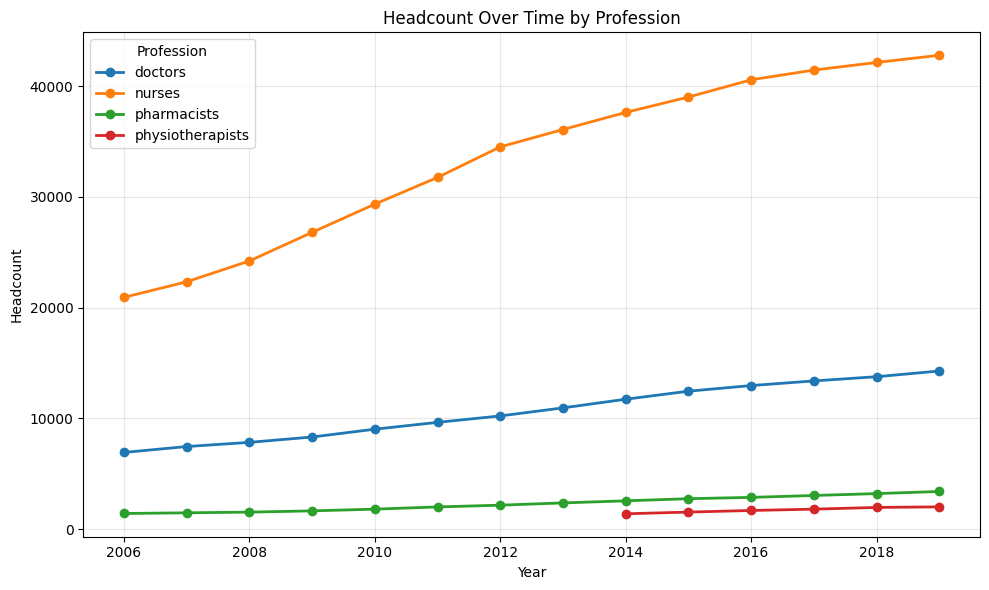

Figure written to /Users/alfredtang/Documents/Projects/gen-e2/gen-e2-data-analysis/artifacts/ps-004-headcount-forecasting/reports/figures/headcount_time_series.png


In [3]:
figure_path = artifacts_root / 'reports' / 'figures' / 'headcount_time_series.png'
figure_path.parent.mkdir(parents=True, exist_ok=True)
plot_df = analysis_df.to_pandas()
plt.figure(figsize=(10, 6))
for profession in sorted(plot_df['profession'].unique()):
    subset = plot_df[plot_df['profession'] == profession].sort_values('year')
    plt.plot(subset['year'], subset['count'], marker='o', linewidth=2, label=profession)
plt.title('Headcount Over Time by Profession')
plt.xlabel('Year')
plt.ylabel('Headcount')
plt.grid(alpha=0.3)
plt.legend(title='Profession')
plt.tight_layout()
plt.savefig(figure_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure written to {figure_path}")

In [4]:
year_range_summary = (
    analysis_df.group_by('profession')
    .agg(
        pl.col('year').min().alias('min_year'),
        pl.col('year').max().alias('max_year'),
        pl.len().alias('row_count')
    )
    .sort('profession')
)
print(year_range_summary)

shape: (4, 4)
┌──────────────────┬──────────┬──────────┬───────────┐
│ profession       ┆ min_year ┆ max_year ┆ row_count │
│ ---              ┆ ---      ┆ ---      ┆ ---       │
│ cat              ┆ i32      ┆ i32      ┆ u32       │
╞══════════════════╪══════════╪══════════╪═══════════╡
│ doctors          ┆ 2006     ┆ 2019     ┆ 14        │
│ nurses           ┆ 2006     ┆ 2019     ┆ 14        │
│ pharmacists      ┆ 2006     ┆ 2019     ┆ 14        │
│ physiotherapists ┆ 2014     ┆ 2019     ┆ 6         │
└──────────────────┴──────────┴──────────┴───────────┘


In [5]:
diff_summary = (
    analysis_df.sort(['profession', 'year'])
    .with_columns(pl.col('count').diff().over('profession').alias('first_diff'))
    .drop_nulls('first_diff')
    .group_by('profession')
    .agg(
        pl.col('first_diff').mean().round(2).alias('mean_diff'),
        pl.col('first_diff').std().round(2).alias('std_diff')
    )
    .sort('profession')
)
print(diff_summary)

shape: (4, 3)
┌──────────────────┬───────────┬──────────┐
│ profession       ┆ mean_diff ┆ std_diff │
│ ---              ┆ ---       ┆ ---      │
│ cat              ┆ f64       ┆ f64      │
╞══════════════════╪═══════════╪══════════╡
│ doctors          ┆ 565.23    ┆ 137.36   │
│ nurses           ┆ 1680.77   ┆ 718.66   │
│ pharmacists      ┆ 152.85    ┆ 49.18    │
│ physiotherapists ┆ 125.2     ┆ 42.56    │
└──────────────────┴───────────┴──────────┘


In [6]:
autocorrelation_rows = []
for profession in analysis_df.select('profession').unique().sort('profession').to_series().to_list():
    series = (
        analysis_df.filter(pl.col('profession') == profession)
        .sort('year')
        .get_column('count')
        .cast(pl.Float64)
    )
    current = series.slice(1)
    lagged = series.slice(0, len(series) - 1)
    corr = pl.DataFrame({'current': current, 'lagged': lagged}).select(pl.corr('current', 'lagged')).item()
    autocorrelation_rows.append({
        'profession': profession,
        'lag_1_autocorrelation': round(corr, 4) if corr is not None else None,
    })
autocorrelation_summary = pl.DataFrame(autocorrelation_rows).sort('profession')
print(autocorrelation_summary)

shape: (4, 2)
┌──────────────────┬───────────────────────┐
│ profession       ┆ lag_1_autocorrelation │
│ ---              ┆ ---                   │
│ str              ┆ f64                   │
╞══════════════════╪═══════════════════════╡
│ doctors          ┆ 0.9983                │
│ nurses           ┆ 0.997                 │
│ pharmacists      ┆ 0.9981                │
│ physiotherapists ┆ 0.989                 │
└──────────────────┴───────────────────────┘


In [7]:
summary_table = (
    analysis_df.sort(['profession', 'year'])
    .group_by('profession')
    .agg(
        pl.col('count').min().alias('min_headcount'),
        pl.col('count').max().alias('max_headcount'),
        pl.col('count').mean().round(2).alias('mean_headcount'),
        pl.col('count').first().alias('first_year_headcount'),
        pl.col('count').last().alias('last_year_headcount')
    )
    .with_columns(
        pl.when(pl.col('last_year_headcount') > pl.col('first_year_headcount'))
        .then(pl.lit('upward'))
        .otherwise(pl.lit('not upward'))
        .alias('trend_direction')
    )
    .select(['profession', 'min_headcount', 'max_headcount', 'mean_headcount', 'trend_direction'])
    .sort('profession')
)
print(summary_table)

shape: (4, 5)
┌──────────────────┬───────────────┬───────────────┬────────────────┬─────────────────┐
│ profession       ┆ min_headcount ┆ max_headcount ┆ mean_headcount ┆ trend_direction │
│ ---              ┆ ---           ┆ ---           ┆ ---            ┆ ---             │
│ cat              ┆ i32           ┆ i32           ┆ f64            ┆ str             │
╞══════════════════╪═══════════════╪═══════════════╪════════════════╪═════════════════╡
│ doctors          ┆ 6931          ┆ 14279         ┆ 10643.07       ┆ upward          │
│ nurses           ┆ 20927         ┆ 42777         ┆ 33532.64       ┆ upward          │
│ pharmacists      ┆ 1421          ┆ 3408          ┆ 2310.64        ┆ upward          │
│ physiotherapists ┆ 1394          ┆ 2020          ┆ 1739.5         ┆ upward          │
└──────────────────┴───────────────┴───────────────┴────────────────┴─────────────────┘
